In [1]:
# %load_ext autoreload
# %autoreload 2

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# Add parent directory to path to import 'deep_ecg' modules
sys.path.append(os.path.abspath(os.path.join('..')))

from load_dataset import load_ptb_dataset
from run import (
    run_closed_set_identification, 
    run_subject_disjoint_identification,
    run_verification,
    run_subject_disjoint_verification,
    run_cross_session_identification,
    run_cross_session_verification
)
from models import DeepECG, ResNet1D
from visualizations import Visualizer

import warnings
warnings.filterwarnings("ignore")

print("Framework loaded successfully.")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

Framework loaded successfully.
Running on: cpu


In [3]:
# --- DATA LOADING (Base Session) ---
print("Loading PTB (All Data) for Random Split Experiments...")

# Load everything. This mixes days and pathologies.
loader = load_ptb_dataset(num_beats=3, merge_strategy="average", cleanup_zip=False)
x_all, y_all = loader.load_all_sessions()

print(f"Data Loaded: {x_all.shape} samples, {len(np.unique(y_all))} subjects")

Loading PTB (All Data) for Random Split Experiments...


Processing signals: 100%|██████████| 290/290 [07:09<00:00,  1.48s/it]

Data Loaded: (73529, 600) samples, 290 subjects



=== TASK 1: Closed-Set Identification (Random Split) ===

[TASK] Closed-Set Identification on cpu
    Epoch 001 | Loss: 3.6135
    Epoch 002 | Loss: 1.6599
    Epoch 003 | Loss: 1.0806
[RESULT] Closed-Set Accuracy: 0.7319


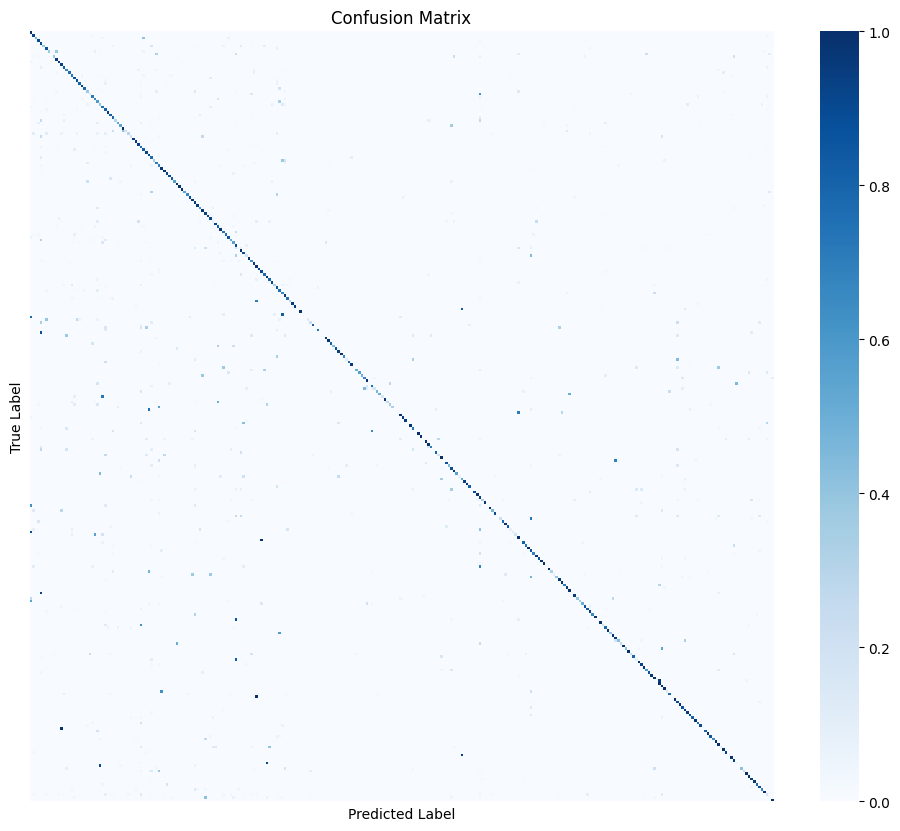


=== TASK 2: Verification (Random Split) ===

[TASK] Verification (Random Split / Closed-Set) on cpu
[INFO] Phase 1: Training feature extractor (Learning Identity)...
    Epoch 001 | Loss: 3.8381
    Epoch 002 | Loss: 1.9234
    Epoch 003 | Loss: 1.2219
[INFO] Phase 2: Computing EER using 'balanced' sampling...
[INFO] Computing T-SNE... this may take a moment.


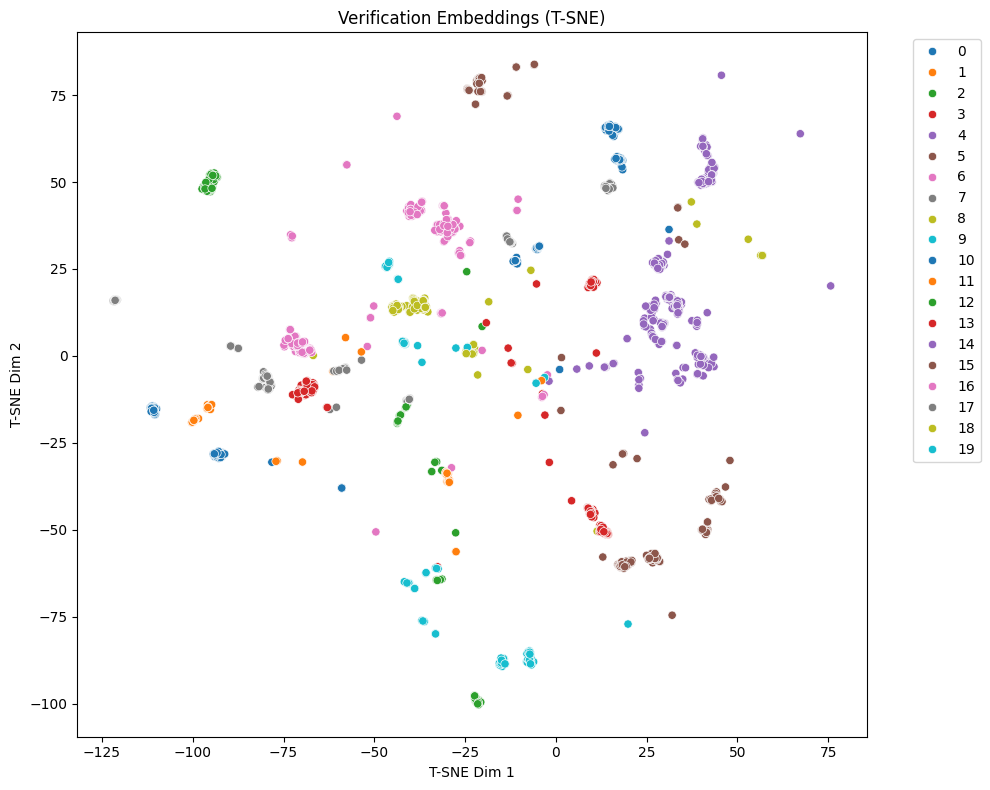

[INFO] Generating 10000 BALANCED pairs (50/50 split)...
[RESULT] Mode: BALANCED | EER: 0.0838 | AUC: 0.9713

=== TASK 3: Subject-Disjoint Verification (Open Set) ===

[TASK] Subject-Disjoint Verification (Open-Set) on cpu
[INFO] Splitting: 203 Training Subjects vs 87 Test Subjects
[INFO] Phase 1: Training on Known Subjects...
    Epoch 001 | Loss: 3.4129
    Epoch 002 | Loss: 1.4926
    Epoch 003 | Loss: 0.8897
[INFO] Phase 2: Computing EER on 87 Unseen Subjects...
[INFO] Generating 10000 BALANCED pairs (50/50 split)...
[RESULT] Mode: BALANCED | EER: 0.0982 | AUC: 0.9636


In [4]:
# --- TASK 1: Closed-Set Identification (Random Split) ---
print("\n=== TASK 1: Closed-Set Identification (Random Split) ===")
acc = run_closed_set_identification(
    x_all, y_all, 
    DeepECG, 
    epochs=3, 
    device=device,
    visualize=True 
)

# --- TASK 2: Verification (Random Split) ---
print("\n=== TASK 2: Verification (Random Split) ===")
metrics_verif = run_verification(
    x_all, y_all, 
    DeepECG, 
    epochs=3, 
    device=device,
    visualize=True
)

# --- TASK 3: Subject-Disjoint Verification (Open Set) ---
print("\n=== TASK 3: Subject-Disjoint Verification (Open Set) ===")
metrics_open = run_subject_disjoint_verification(
    x_all, y_all, 
    DeepECG, 
    train_subject_ratio=0.7, 
    epochs=3, 
    device=device,
    visualize=False
)

In [2]:
# --- TASK 4: Biometric Regimes Evaluation ---
print("\n=== TASK 4: Biometric Regimes ===")

# A. SHORT-TERM (Day 1 Stability)
print("\n[A] Loading Short-Term Data (Day 1 Rec 1 vs Rest)...")
loader_st = load_ptb_dataset(num_beats=3, enrollment_mode='short_term', cleanup_zip=False)
x_st_enr, y_st_enr = loader_st.load_session("Session_1")
x_st_prb, y_st_prb = loader_st.load_session("Session_2")
print(f"    Short-Term Shapes: Enroll {x_st_enr.shape}, Probe {x_st_prb.shape}")

print("    Running Short-Term Verification...")
run_cross_session_verification(x_st_enr, y_st_enr, x_st_prb, y_st_prb, DeepECG, epochs=3, device=device, visualize=False)


# B. LONG-TERM (Template Aging)
print("\n[B] Loading Long-Term Data (Day 1 vs Future)...")
loader_lt = load_ptb_dataset(num_beats=3, enrollment_mode='long_term', cleanup_zip=False)
x_lt_enr, y_lt_enr = loader_lt.load_session("Session_1")
x_lt_prb, y_lt_prb = loader_lt.load_session("Session_2")
print(f"    Long-Term Shapes: Enroll {x_lt_enr.shape}, Probe {x_lt_prb.shape}")

print("    Running Long-Term Verification...")
run_cross_session_verification(x_lt_enr, y_lt_enr, x_lt_prb, y_lt_prb, DeepECG, epochs=3, device=device, visualize=False)


# C. MAXIMAL (Very Long Term)
print("\n[C] Loading Maximal Interval Data (Strict VLT)...")
loader_max = load_ptb_dataset(num_beats=3, enrollment_mode='maximal', cleanup_zip=False)
x_mx_enr, y_mx_enr = loader_max.load_session("Session_1")
x_mx_prb, y_mx_prb = loader_max.load_session("Session_2")
print(f"    Maximal Shapes: Enroll {x_mx_enr.shape}, Probe {x_mx_prb.shape}")

print("    Running Maximal Verification...")
run_cross_session_verification(x_mx_enr, y_mx_enr, x_mx_prb, y_mx_prb, DeepECG, epochs=3, device=device, visualize=False)


=== TASK 4: Biometric Regimes ===

[A] Loading Short-Term Data (Day 1 Rec 1 vs Rest)...


Processing Session_2: 100%|██████████| 290/290 [03:23<00:00,  1.43it/s]


    Short-Term Shapes: Enroll (37637, 600), Probe (38354, 600)
    Running Short-Term Verification...

[TASK] Cross-Session Verification (EER) on cpu
[INFO] Phase 1: Training Feature Extractor on Session 1...
    Epoch 001 | Loss: 3.7130
    Epoch 002 | Loss: 1.8090
    Epoch 003 | Loss: 1.2297
[INFO] Phase 2: Extracting Embeddings for Pairing...
[INFO] Generating 10000 Cross-Session Pairs (balanced)...
[RESULT] Cross-Session EER: 0.0804 | AUC: 0.9741

[B] Loading Long-Term Data (Day 1 vs Future)...


Processing Session_2: 100%|██████████| 290/290 [04:01<00:00,  1.20it/s]


    Long-Term Shapes: Enroll (14849, 600), Probe (32557, 600)
    Running Long-Term Verification...

[TASK] Cross-Session Verification (EER) on cpu
[INFO] Phase 1: Training Feature Extractor on Session 1...
    Epoch 001 | Loss: 3.4080
    Epoch 002 | Loss: 1.7928
    Epoch 003 | Loss: 1.1617
[INFO] Phase 2: Extracting Embeddings for Pairing...
[INFO] Generating 10000 Cross-Session Pairs (balanced)...
[RESULT] Cross-Session EER: 0.2662 | AUC: 0.8146

[C] Loading Maximal Interval Data (Strict VLT)...


Processing Session_2: 100%|██████████| 290/290 [01:09<00:00,  4.17it/s]


    Maximal Shapes: Enroll (14434, 600), Probe (12696, 600)
    Running Maximal Verification...

[TASK] Cross-Session Verification (EER) on cpu
[INFO] Phase 1: Training Feature Extractor on Session 1...
    Epoch 001 | Loss: 3.4373
    Epoch 002 | Loss: 1.7171
    Epoch 003 | Loss: 1.0796
[INFO] Phase 2: Extracting Embeddings for Pairing...
[INFO] Generating 10000 Cross-Session Pairs (balanced)...
[RESULT] Cross-Session EER: 0.2678 | AUC: 0.8176


{'eer': 0.26780000000140464, 'auc': 0.81756908}

In [ ]:
# --- TASK 5: Blind Segmentation (Long-Term) ---
print("\n=== TASK 5: Blind Segmentation (Long-Term) ===")

blind_params = {
    'mode': 'blind',
    'window_len': 5.0,  
    'stride': 2.0,      
    'bandpass': True,
    'normalize': 'zscore'
}

# We use 'long_term' mode to test robustness to aging
loader_blind = load_ptb_dataset(
    num_beats=1, 
    enrollment_mode='long_term', 
    preprocessing_params=blind_params, 
    cleanup_zip=False
)

x_blind_enr, y_blind_enr = loader_blind.load_session("Session_1")
x_blind_prb, y_blind_prb = loader_blind.load_session("Session_2")
print(f"Blind Data Shapes: Enroll {x_blind_enr.shape}, Probe {x_blind_prb.shape}")

print("\n[Blind] Identification")
run_cross_session_identification(x_blind_enr, y_blind_enr, x_blind_prb, y_blind_prb, DeepECG, epochs=10, device=device)

print("\n[Blind] Verification")
run_cross_session_verification(x_blind_enr, y_blind_enr, x_blind_prb, y_blind_prb, DeepECG, epochs=10, device=device, visualize=True)